# Random Forest Regressor - NSAC

In [14]:
# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

# Read data from Google Drive.
# Data is already clean.

file_path = "/content/drive/MyDrive/Doutorado CAV 2024/Análises no Colab/JSTARS_153_samples.csv"
data = pd.read_csv(file_path, decimal=',')

# Separate response and predictor variables

X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

In [11]:
X.head()

,Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9,Band 10,...,Band 198,Band 199,Band 200,Band 201,Band 202,Band 203,Band 204,Band 205,Band 206,Band 207
0,0.0151,0.0103,0.0087,0.0127,0.0118,0.0105,0.0124,0.0118,0.0132,0.0129,...,0.0274,0.0262,0.0282,0.0244,0.0253,0.0201,0.0208,0.0193,0.0188,0.0105
1,0.0141,0.0079,0.0097,0.0129,0.0105,0.0111,0.0114,0.0122,0.0132,0.0127,...,0.0273,0.0257,0.0246,0.0230,0.0252,0.0205,0.0227,0.0188,0.0203,0.0125
2,0.0102,0.0074,0.0081,0.0094,0.0096,0.0107,0.0109,0.0101,0.0118,0.0127,...,0.0275,0.0256,0.0280,0.0234,0.0224,0.0196,0.0215,0.0175,0.0183,0.0144
3,0.0128,0.0108,0.0105,0.0108,0.0103,0.0122,0.0122,0.0120,0.0126,0.0126,...,0.0276,0.0241,0.0281,0.0243,0.0221,0.0220,0.0204,0.0177,0.0187,0.0138
4,0.0128,0.0106,0.0095,0.0103,0.0095,0.0126,0.0130,0.0110,0.0120,0.0138,...,0.0267,0.0254,0.0251,0.0251,0.0226,0.0192,0.0208,0.0170,0.0187,0.0123


In [12]:
y.head()

,V_hectare
0,359.184
1,377.143
2,343.643
3,320.322
4,380.408


In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import time
import numpy as np


# ==============================================================================
# PREPROCESSING - APPLIED TO TRAINING DATA
# ==============================================================================

# PCA Configuration
# Apply PCA to the training data and transform both training and test data
pca_basica_rf = PCA(n_components=3, svd_solver='full')
X_train_pca = pca_basica_rf.fit_transform(X_train) # PCA applied to training data
X_test_pca  = pca_basica_rf.transform(X_test)   # PCA applied to test data


# ==============================================================================
# MODEL INITIALIZATION AND TRAINING
# ==============================================================================

# Random Forest Regressor Configuration
print("\nRandom Forest Regressor Configuration:")
rf_restrito_params = {
        'n_estimators': 35,
        'max_depth': 10,
        'min_samples_split': 18,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'max_samples': 0.6,
        'random_state': 42,
        'n_jobs': -1
    }
rf_restrito = RandomForestRegressor(**rf_restrito_params)

# Training the Random Forest model
print("\nTraining Random Forest Regressor...")

# Calculate training time
start_training_time = time.perf_counter()
rf_restrito.fit(X_train_pca, y_train)
end_training_time = time.perf_counter() - start_training_time
print(f"Random Forest Training Time: {end_training_time:.5f} seconds")


# ==============================================================================
# RESULTS AND METRICS
# ==============================================================================

# A. PCA Metrics (from global fit on X_train)
print("\n========================================")
print("A. PCA Metrics")
print("========================================")
print(f"  Number of Components: {pca_basica_rf.n_components_}")
print(f"  Explained Variance Ratio per Component: {pca_basica_rf.explained_variance_ratio_}")
print(f"  Cumulative Explained Variance: {pca_basica_rf.explained_variance_ratio_.sum() * 100:.2f}%")
print(f"  Variance Value per Component: {pca_basica_rf.explained_variance_}")

# B. Training Metrics (on globally PCA-transformed data)
print("\n========================================")
print("B. Training Metrics (on PCA-transformed data)")
print("========================================")
r2_rf_train = rf_restrito.score(X_train_pca, y_train)
y_pred_train_rf = rf_restrito.predict(X_train_pca)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
mse_rf_train = mean_squared_error(y_train, y_pred_train_rf)
mae_rf_train = mean_absolute_error(y_train, y_pred_train_rf)
rrmse_rf_train = (rmse_rf_train / np.mean(y_train)) * 100

print(f"  R² (Training): {r2_rf_train:.3f}")
print(f"  RMSE (Training): {rmse_rf_train:.2f}")
print(f"  MSE (Training): {mse_rf_train:.2f}")
print(f"  MAE (Training): {mae_rf_train:.2f}")
print(f"  RRMSE (Training): {rrmse_rf_train:.2f}%")

# C. Test Metrics (on globally PCA-transformed data)
print("\n========================================")
print("C. Test Metrics (on PCA-transformed data)")
print("========================================")
r2_rf_test = rf_restrito.score(X_test_pca, y_test)

# Calculate prediction time on test data
start_prediction_time = time.perf_counter()
y_pred_test_rf = rf_restrito.predict(X_test_pca)
end_prediction_time = time.perf_counter() - start_prediction_time

rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mse_rf_test = mean_squared_error(y_test, y_pred_test_rf)
mae_rf_test = mean_absolute_error(y_test, y_pred_test_rf)
rrmse_rf_test = (rmse_rf_test / np.mean(y_test)) * 100

print(f"  R² (Test): {r2_rf_test:.3f}")
print(f"  RMSE (Test): {rmse_rf_test:.2f}")
print(f"  MSE (Test): {mse_rf_test:.2f}")
print(f"  MAE (Test): {mae_rf_test:.2f}")
print(f"  RRMSE (Test): {rrmse_rf_test:.2f}%")
print(f"  Difference (Train R² - Test R²): {r2_rf_train - r2_rf_test:.4f}")
print(f"\nRandom Forest Prediction Time: {end_prediction_time:.5f} seconds")

# D. Cross-Validation Metrics (on raw X_train with pipeline)
print("\n========================================")
print("D. Cross-Validation Metrics (10-folds on raw training data with Pipeline)")
print("========================================")

# Define the pipeline for cross-validation
# PCA is applied to unscaled data as per the original setup in this notebook
pipeline_rf_cv = Pipeline([
     ('pca', PCA(n_components=3, svd_solver='full')),
     ('rf', RandomForestRegressor(**rf_restrito_params)) # Use a fresh instance for CV
])

# Define cross-validation strategies
# KFold for generating predictions (to avoid data leakage across folds)
cv_predict = KFold(n_splits=10, shuffle=True, random_state=42)
# RepeatedKFold for more robust error estimation for scoring
cv_score = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

# Generate cross-validated predictions on the training data
# y_pred_cv_rf contains the predictions from cross_val_predict, representing an overall prediction for the entire training set
y_pred_cv_rf = cross_val_predict(pipeline_rf_cv, X_train, y_train, cv=cv_predict, n_jobs=-1)

# Calculate cross-validation scores for each fold
# These are the R² and RMSE scores for each of the 10 folds, repeated 5 times for 'cv_score'
cv_scores_r2 = cross_val_score(pipeline_rf_cv, X_train, y_train, cv=cv_score, scoring='r2', n_jobs=-1)
cv_scores_rmse = -cross_val_score(pipeline_rf_cv, X_train, y_train, cv=cv_score, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Get average training and scoring times for cross-validation
cv_timing_results = cross_validate(pipeline_rf_cv, X_train, y_train, cv=cv_score, scoring='r2', n_jobs=-1)
print(f"\nAverage Cross-Validation Fit Time: {cv_timing_results['fit_time'].mean():.5f} seconds")
print(f"Average Cross-Validation Score Time: {cv_timing_results['score_time'].mean():.5f} seconds")


print(f"\n===== Metrics from Cross-Validated Predictions (cross_val_predict) ====")
# These R² and other metrics are calculated using the predictions generated by cross_val_predict
# This provides a single set of overall metrics across all folds, often used for plotting or aggregated performance.
print(f"  Overall R² (cross_val_predict): {r2_score(y_train, y_pred_cv_rf):.4f}")
print(f"  RMSE (cross_val_predict): {np.sqrt(mean_squared_error(y_train, y_pred_cv_rf)):.2f}")
print(f"  MSE (cross_val_predict): {mean_squared_error(y_train, y_pred_cv_rf):.2f}")
print(f"  MAE (cross_val_predict): {mean_absolute_error(y_train, y_pred_cv_rf):.2f}")
print(f"  RRMSE (cross_val_predict): {(np.sqrt(mean_squared_error(y_train, y_pred_cv_rf)) / np.mean(y_train)) * 100:.2f}%")

print(f"\n===== Metrics from Individual Cross-Validation Folds (cross_val_score) ====")
# These metrics represent the average performance and variability across the individual cross-validation folds.
# They indicate the model's consistency and robustness (5 repetitons).
print(f"  Mean R² (cross_val_score): {cv_scores_r2.mean():.4f}") # Average R² across all folds
print(f"  Mean RMSE (cross_val_score): {cv_scores_rmse.mean():.4f}")
print(f"  Standard Deviation R² (cross_val_score): {cv_scores_r2.std():.4f}")
print(f"  Standard Deviation RMSE (cross_val_score): {cv_scores_rmse.std():.4f}")
print(f"  Range R² (cross_val_score): {cv_scores_r2.min():.4f} - {cv_scores_r2.max():.4f}")


Random Forest Regressor Configuration:

Training Random Forest Regressor...
Random Forest Training Time: 0.15849 seconds

A. PCA Metrics
  Number of Components: 3
  Explained Variance Ratio per Component: [0.72939313 0.23606104 0.01407684]
  Cumulative Explained Variance: 97.95%
  Variance Value per Component: [0.02282914 0.00738843 0.00044059]

B. Training Metrics (on PCA-transformed data)
  R² (Training): 0.667
  RMSE (Training): 63.98
  MSE (Training): 4093.56
  MAE (Training): 50.68
  RRMSE (Training): 14.96%

C. Test Metrics (on PCA-transformed data)
  R² (Test): 0.571
  RMSE (Test): 76.78
  MSE (Test): 5894.73
  MAE (Test): 59.03
  RRMSE (Test): 18.12%
  Difference (Train R² - Test R²): 0.0957

Random Forest Prediction Time: 0.01323 seconds

D. Cross-Validation Metrics (10-folds on raw training data with Pipeline)

Average Cross-Validation Fit Time: 0.15593 seconds
Average Cross-Validation Score Time: 0.03686 seconds

===== Metrics from Cross-Validated Predictions (cross_val_pre

# PCA Analysis

In [5]:
# This section identifies the most important Principal Components (PCs).
# It answers: "How much does the model's performance degrade when information from a PC is shuffled?"
# Step-by-step process:
# 1. The model is trained normally.
# 2. A PC's information is shuffled (permuted).
# 3. The increase in error (or drop in R²) is measured.
# 4. PCs whose permutation causes the largest performance drop are considered most important.

from sklearn.inspection import permutation_importance
import numpy as np

perm_importance = permutation_importance(
    rf_restrito,
    X_train_pca,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

pc_importances = perm_importance.importances_mean

# Select the top K most important PCs
top_k = 3
top_pcs = np.argsort(pc_importances)[::-1][:top_k]

print("Most important PCs:")
for pc in top_pcs:
    print(f"PC{pc+1} – importance = {pc_importances[pc]:.4f}")

Most important PCs:
PC1 – importance = 0.5838
PC2 – importance = 0.2487
PC3 – importance = 0.0459


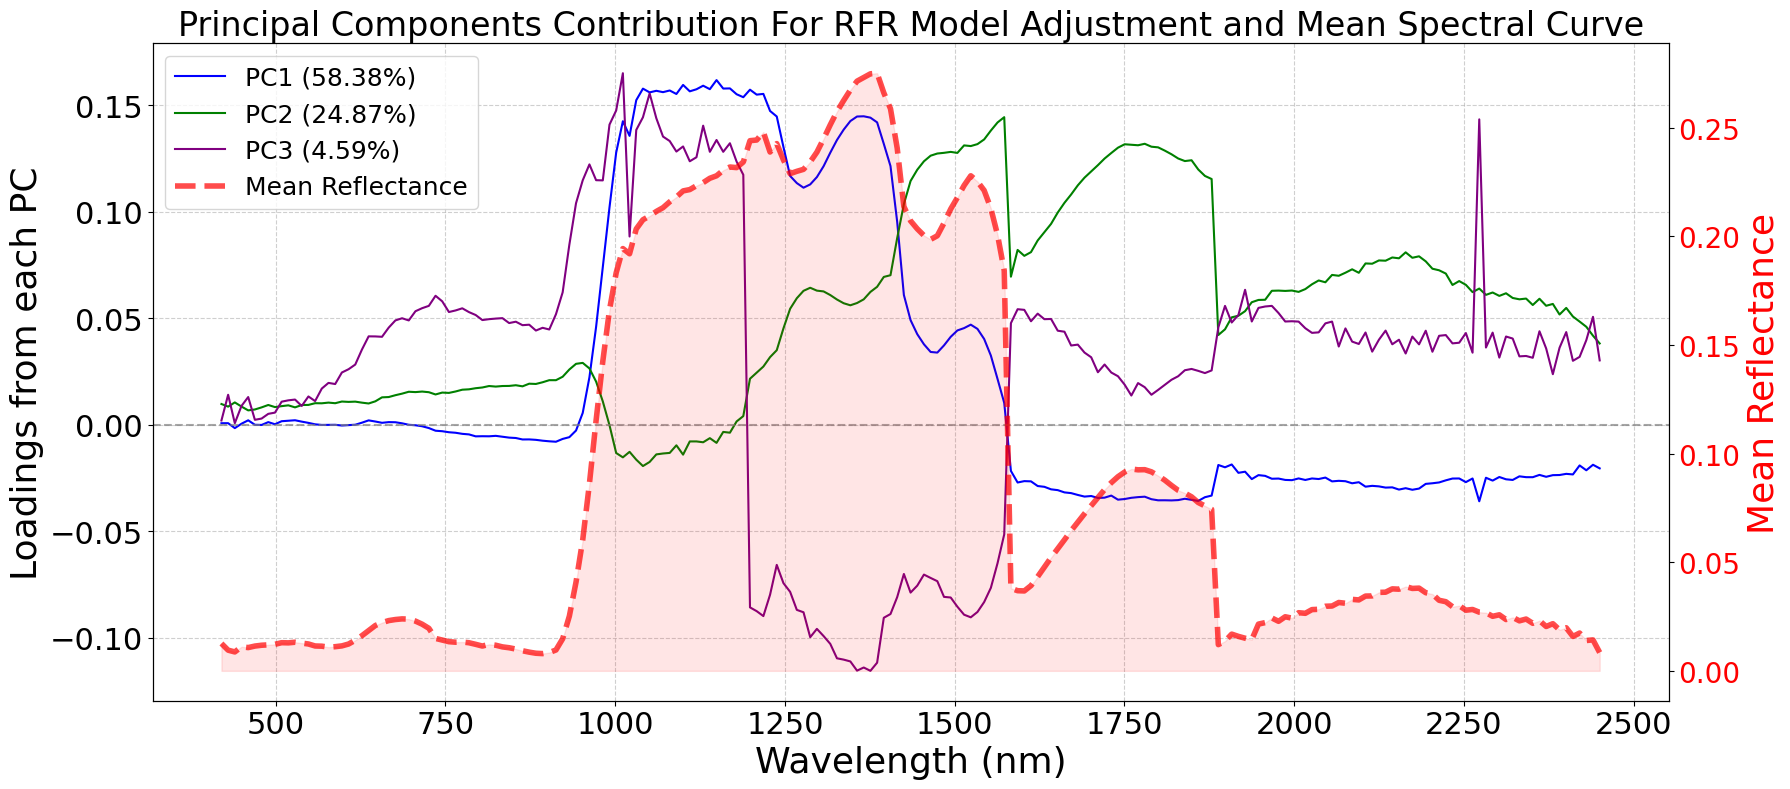

In [6]:
# Enhanced Plot for PCA Loadings and Mean Spectral Curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe

# --- 1. Define EnMAP wavelengths for 207 bands ---
# Assuming 207 bands are linearly distributed between 420nm and 2450nm (standard EnMAP range)
# The number of bands is derived from X.shape[1], which is 207 in this notebook's context.
enmap_wavelengths = np.linspace(420, 2450, X.shape[1])

# --- 2. Calculate the mean spectral curve (mean reflectance for each band) ---
mean_spectral_curve = X.mean(axis=0)

# --- 3. Retrieve PCA loadings and permutation importances ---
# These objects are assumed to be available from previous cell executions for the RF model.
# pc_importances contains the permutation importances of PCs for RF.
# top_pcs contains the indices of the most important PCs.
loadings = pca_basica_rf.components_

# --- 4. Create the plot with a secondary y-axis ---
fig, ax1 = plt.subplots(figsize=(18, 8))

# Define colors for the PCA loadings
colors = ['blue', 'green', 'purple'] # Example colors for top 3 PCs

# Plot PCA Loadings on ax1 (left y-axis)
for i, pc_idx in enumerate(top_pcs):
    ax1.plot(
        enmap_wavelengths,
        loadings[pc_idx],
        label=f'PC{pc_idx+1} ({pc_importances[pc_idx]*100:.2f}%)',
        color=colors[i],
        linewidth=1.5
    )

ax1.axhline(0, linestyle='--', color='gray', alpha=0.7)
ax1.set_xlabel('Wavelength (nm)', fontsize=26)
ax1.set_ylabel('Loadings from each PC', fontsize=26, color='black')
ax1.tick_params(axis='y', labelcolor='black', labelsize=22)
ax1.tick_params(axis='x', labelsize=22)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis for the mean spectral curve
ax2 = ax1.twinx()
ax2.plot(enmap_wavelengths, mean_spectral_curve, label='Mean Reflectance', color='red', linestyle='--', linewidth=4, alpha=0.7)
ax2.fill_between(enmap_wavelengths, mean_spectral_curve, color='red', alpha=0.1) # Added fill here
ax2.set_ylabel('Mean Reflectance', fontsize=26, color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=20)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=18)

ax1.set_title('Principal Components Contribution For RFR Model Adjustment and Mean Spectral Curve', fontsize=24)
plt.tight_layout()

# Save at 600 dpi
#plt.savefig('pca_loadings_rf.png', dpi=600)
plt.show()

# Make plot border lines darker
ax1.spines['left'].set_edgecolor('black')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_edgecolor('black')
ax1.spines['bottom'].set_linewidth(1.5)
ax2.spines['right'].set_edgecolor('black')
ax2.spines['right'].set_linewidth(1.5)
ax2.spines['top'].set_edgecolor('black')

# Metrics - Observed vs Predict

R² on TEST Data (Restricted RF): 0.571
RMSE (Restricted RF): 76.78
MSE (Restricted RF): 5894.73
MAE (Restricted RF): 59.03
RRMSE (Restricted RF): 18.12%
R² on TRAINING Data (Restricted RF): 0.667
R² on TEST Data (Restricted RF): 0.571


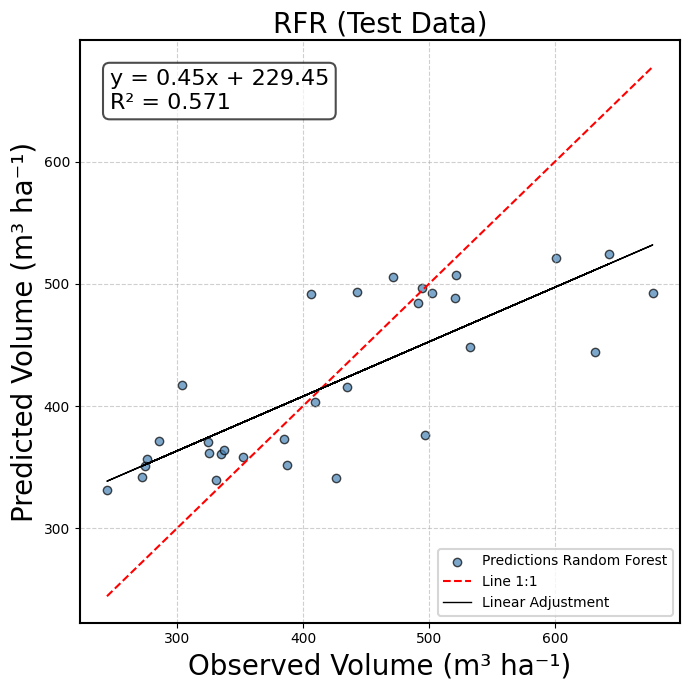

In [7]:
# Random Forest Regressor (rf_restrito) Plot and Metrics
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

# 1. Make predictions and evaluate performance on TEST data
y_pred_rf_restrito = rf_restrito.predict(X_test_pca)

# Calculate metrics on TEST data
r2_rf_restrito = r2_score(y_test, y_pred_rf_restrito)
rmse_rf_restrito = np.sqrt(mean_squared_error(y_test, y_pred_rf_restrito))
mse_rf_restrito = mean_squared_error(y_test, y_pred_rf_restrito)
mae_rf_restrito = mean_absolute_error(y_test, y_pred_rf_restrito)
rrmse_rf_restrito = (rmse_rf_restrito / np.mean(y_test))*100


# Print results to console
print(f"R² on TEST Data (Restricted RF): {r2_rf_restrito:.3f}")
print(f"RMSE (Restricted RF): {rmse_rf_restrito:.2f}")
print(f"MSE (Restricted RF): {mse_rf_restrito:.2f}")
print(f"MAE (Restricted RF): {mae_rf_restrito:.2f}")
print(f"RRMSE (Restricted RF): {rrmse_rf_restrito:.2f}%")

# Evaluate training and test data R²
print(f"R² on TRAINING Data (Restricted RF): {rf_restrito.score(X_train_pca, y_train):.3f}")
print(f"R² on TEST Data (Restricted RF): {rf_restrito.score(X_test_pca, y_test):.3f}")

# 2. Scatter plot with 1:1 line and equation
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_rf_restrito, color='steelblue', edgecolor='k', alpha=0.7, label='Predictions Random Forest')

# 1:1 line (perfect prediction)
min_val = min(y_test.min(), y_pred_rf_restrito.min())
max_val = max(y_test.max(), y_pred_rf_restrito.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Line 1:1')

# Fit a simple linear regression for visualization
reg_line_rf_restrito = LinearRegression()
reg_line_rf_restrito.fit(y_test.values.reshape(-1, 1), y_pred_rf_restrito.reshape(-1, 1))
slope_rf_restrito = reg_line_rf_restrito.coef_[0][0]
intercept_rf_restrito = reg_line_rf_restrito.intercept_[0]
y_fit_rf_restrito = reg_line_rf_restrito.predict(y_test.values.reshape(-1, 1))

# Fitted line
plt.plot(y_test, y_fit_rf_restrito, color='black', linewidth=1, label='Linear Adjustment')

# Text with equation and R²
eq_text_rf_restrito = f"y = {slope_rf_restrito:.2f}x + {intercept_rf_restrito:.2f}\nR² = {r2_rf_restrito:.3f}"
plt.text(0.05, 0.95, eq_text_rf_restrito, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Plot settings
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predicted Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("RFR (Test Data)").set_fontsize(20)

legend = plt.legend(frameon=True) # Explicitly set frameon=True for the legend
legend.get_frame().set_linewidth(1.5) # Set linewidth of the legend frame
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5) # Increase linewidth for darker border

plt.tight_layout()
# Save figure at 600 dpi
#plt.savefig('rf_restrito_test.png', dpi=600)
plt.show()

# Cross-Validation


Global Coefficients from cross_val_predict - Returns only 1 metric
Overall R² of the model (CV for RF with Pipeline): 0.568
RMSE (CV for RF with Pipeline): 72.81
MSE (CV for RF with Pipeline): 5300.95
MAE (CV for RF with Pipeline): 57.53
RRMSE (CV for RF with Pipeline): 17.06%

Average Coefficients from Cross_Val_Scores - Returns the average across folds - Suitable for ANOVA comparison
Mean Coefficient of Determination (10-folds with Pipeline):
  Mean R²: 0.5473
  Std:   0.1407
  Range: 0.2863 - 0.7123
 Mean RMSE for RF CV with Pipeline: 70.6126


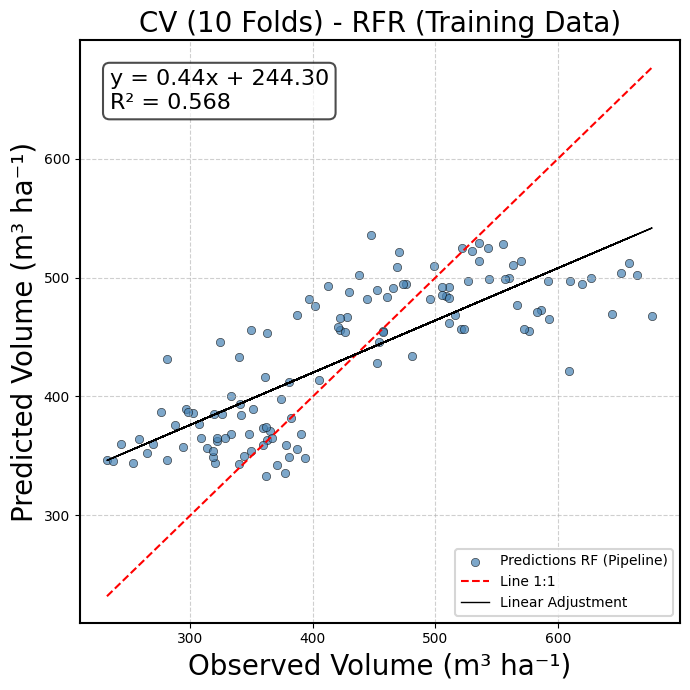

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure y is a numpy array
y_full_dataset = data['V_hectare'].values


# 1. Create the Pipeline
# Reusing the number of components from the already fitted PCA (pca_basica_rf).
# Fitting StandardScaler and PCA within each CV fold is the correct approach to avoid data leakage.
pipeline_rf = Pipeline([
    #('scaler', StandardScaler()), # Normalization was removed as it worsened the model
    ('pca', PCA(n_components=3, svd_solver='full')),
    ('rf', rf_restrito) # Uses the previously defined rf_restrito model
])

# 2. 10-fold cross-validation using the Pipeline
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

y_pred_cv_rf_pipeline = cross_val_predict(pipeline_rf, X_train, y_train, cv=cv_strategy, n_jobs=-1)

# 3. Evaluate cross-validation metrics
r2_cv_rf_pipeline = r2_score(y_train, y_pred_cv_rf_pipeline)
rmse_cv_rf_pipeline = np.sqrt(mean_squared_error(y_train, y_pred_cv_rf_pipeline))
mse_cv_rf_pipeline = mean_squared_error(y_train, y_pred_cv_rf_pipeline)
mae_cv_rf_pipeline = mean_absolute_error(y_train, y_pred_cv_rf_pipeline)
rrmse_cv_rf_pipeline = (rmse_cv_rf_pipeline / np.mean(y_full_dataset))*100

print(f"\nGlobal Coefficients from cross_val_predict - Returns only 1 metric")
print(f"Overall R² of the model (CV for RF with Pipeline): {r2_cv_rf_pipeline:.3f}")
print(f"RMSE (CV for RF with Pipeline): {rmse_cv_rf_pipeline:.2f}")
print(f"MSE (CV for RF with Pipeline): {mse_cv_rf_pipeline:.2f}")
print(f"MAE (CV for RF with Pipeline): {mae_cv_rf_pipeline:.2f}")
print(f"RRMSE (CV for RF with Pipeline): {rrmse_cv_rf_pipeline:.2f}%")

# Calculate R² and RMSE values for each of the 10 folds using KFold strategy (without repetitions).
cv_scores_rf_pipeline = cross_val_score(pipeline_rf, X_train, y_train, cv=cv_strategy, scoring='r2', n_jobs=-1)
cv_scores_rf_pipeline_rmse = -cross_val_score(pipeline_rf, X_train, y_train, cv=cv_strategy, scoring='neg_root_mean_squared_error', n_jobs=-1)


print(f"\nAverage Coefficients from Cross_Val_Scores - Returns the average across folds - Suitable for ANOVA comparison")
print(f"Mean Coefficient of Determination (10-folds with Pipeline):")
print(f"  Mean R²: {cv_scores_rf_pipeline.mean():.4f}")
print(f"  Std:   {cv_scores_rf_pipeline.std():.4f}")
print(f"  Range: {cv_scores_rf_pipeline.min():.4f} - {cv_scores_rf_pipeline.max():.4f}")
print(f" Mean RMSE for RF CV with Pipeline: {cv_scores_rf_pipeline_rmse.mean():.4f}")


# 4. Observed vs. Predicted Plot with Regression Line
slope_rf_cv_pipeline, intercept_rf_cv_pipeline, r_value_rf_cv_pipeline, p_value_rf_cv_pipeline, std_err_rf_cv_pipeline = linregress(y_train, y_pred_cv_rf_pipeline)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_train, y=y_pred_cv_rf_pipeline, color="steelblue", edgecolor='k', alpha=0.7, label='Predictions RF (Pipeline)')

# 1:1 line (perfect prediction)
min_val_cv = min(y_full_dataset.min(), y_pred_cv_rf_pipeline.min())
max_val_cv = max(y_full_dataset.max(), y_pred_cv_rf_pipeline.max())
plt.plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], 'r--', label='Line 1:1', linewidth=1.5)

# Fitted line
plt.plot(y_train, intercept_rf_cv_pipeline + slope_rf_cv_pipeline*y_train, color='black', linewidth=1, label='Linear Adjustment')

# Text with equation and R² (from the adjusted model)
eq_text_rf_cv_pipeline = f"y = {slope_rf_cv_pipeline:.2f}x + {intercept_rf_cv_pipeline:.2f}\nR² = {r2_cv_rf_pipeline:.3f}"
plt.text(0.05, 0.95, eq_text_rf_cv_pipeline, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Plot settings
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predicted Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("CV (10 Folds) - RFR (Training Data)").set_fontsize(20)
legend = plt.legend(frameon=True)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
# Save figure at 600 dpi
#plt.savefig('rf_cv_pipeline_train.png', dpi=600)
plt.show()